# Hourly Mean O3 — Diurnal Pattern of Spatial Mean

**Goal**: How does the spatial-mean O3 level vary by time-of-day (hour slot)?

**Analyses**
1. μ(h) — mean of spatial mean by slot (pooled all months)
2. μ_m(h) — monthly breakdown (each month pooled across 2022–2025)
3. Day-to-day SD of spatial mean σ_b(h) — how much the mean level fluctuates day to day per slot

**Data**: Same cache as `hourly_variability_sources_041326.ipynb`

In [1]:
import sys, pickle, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

warnings.filterwarnings('ignore')

sys.path.append("/Users/joonwonlee/Documents/GEMS_TCO-1/src")
from GEMS_TCO import configuration as config

YEARS         = ['2022', '2023', '2024', '2025']
MONTHS        = [4, 5, 6, 7, 8, 9]
N_SLOTS       = 8
MONTH_NAMES   = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}
SLOT_LABELS   = [f'h{h}' for h in range(N_SLOTS)]
MONTH_LABELS  = [MONTH_NAMES[m] for m in MONTHS]

blues        = cm.Blues(np.linspace(0.30, 0.95, N_SLOTS))
month_colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(MONTHS)))

OUT_DIR  = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_mean/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CACHE_PATH = Path("/Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_variability_sources/df_spatial_stats_cache.pkl")
print("Setup done.")

Setup done.


In [2]:
df = pd.read_pickle(CACHE_PATH)
print(f"Loaded: {len(df)} rows")
print(f"Years : {sorted(df['year'].unique())}")
print(f"Months: {sorted(df['month'].unique())}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Loaded: 5808 rows
Years : [2022, 2023, 2024, 2025]
Months: [4, 5, 6, 7, 8, 9]
Columns: ['year', 'month', 'day_idx', 'slot', 'hours_elapsed', 'spatial_mean', 'spatial_std', 'sem_lat_lag1', 'sem_lon_lag1', 'n_obs', 'spatial_mean_c']


,year,month,day_idx,slot,hours_elapsed,spatial_mean,spatial_std,sem_lat_lag1,sem_lon_lag1,n_obs,spatial_mean_c
0,2022,4,0,0,457992.933333,238.456342,3.127380,3.532623,3.367905,17940,2.994124
1,2022,4,0,1,457993.883333,238.205593,3.294163,4.003095,3.861747,17891,2.743374
2,2022,4,0,2,457994.883333,238.426875,3.503113,4.693011,4.628364,17974,2.964656


In [3]:
# ── Pooled (all months) ───────────────────────────────────────────────────────
pooled_mean = df.groupby('slot')['spatial_mean'].mean().values      # μ(h)
pooled_std  = df.groupby('slot')['spatial_mean'].std().values       # σ_b(h) day-to-day SD

# ── Monthly breakdown ─────────────────────────────────────────────────────────
monthly_mean = (
    df.groupby(['month', 'slot'])['spatial_mean'].mean()
      .unstack('slot').rename(columns=lambda h: f'h{int(h)}')
      .reindex(MONTHS)
)
monthly_mean.index = [MONTH_NAMES[m] for m in monthly_mean.index]

monthly_std = (
    df.groupby(['month', 'slot'])['spatial_mean'].std()
      .unstack('slot').rename(columns=lambda h: f'h{int(h)}')
      .reindex(MONTHS)
)
monthly_std.index = [MONTH_NAMES[m] for m in monthly_std.index]

# Add All row
_all_mean = df.groupby('slot')['spatial_mean'].mean().rename(lambda h: f'h{int(h)}')
_all_std  = df.groupby('slot')['spatial_mean'].std().rename(lambda h: f'h{int(h)}')
monthly_mean = pd.concat([monthly_mean,
    pd.DataFrame([_all_mean.values], index=['All'], columns=_all_mean.index)])
monthly_std = pd.concat([monthly_std,
    pd.DataFrame([_all_std.values],  index=['All'], columns=_all_std.index)])

print("μ(h) by month × slot  (DU):")
print(monthly_mean.round(2).to_string())
print()
print("σ_b(h) by month × slot  (DU)  — day-to-day SD of spatial mean:")
print(monthly_std.round(2).to_string())

μ(h) by month × slot  (DU):
slot      h0      h1      h2      h3      h4      h5      h6      h7
Apr   246.99  246.69  246.52  246.84  247.47  247.16  247.28  248.26
May   243.52  243.42  243.28  243.44  243.55  243.74  244.12  245.42
Jun   244.81  244.51  244.13  243.95  244.19  244.27  245.10  247.06
Jul   250.30  249.90  249.38  249.21  249.43  249.80  250.39  251.90
Aug   254.28  253.94  253.85  253.91  254.63  254.66  255.29  255.71
Sep   253.15  252.35  252.03  251.95  252.13  252.90  253.37  255.12
All   248.83  248.46  248.19  248.21  248.56  248.75  249.25  250.57

σ_b(h) by month × slot  (DU)  — day-to-day SD of spatial mean:
slot     h0     h1     h2     h3     h4     h5     h6     h7
Apr   10.57  10.54  10.47  11.44  14.68  10.55  10.54  10.23
May    4.53   4.49   4.39   4.23   4.37   4.40   4.48   4.56
Jun    3.27   3.32   3.43   3.43   3.41   3.43   3.30   3.11
Jul    6.60   6.57   6.47   6.41   6.32   6.46   6.31   6.74
Aug    6.99   6.95   7.01   6.99   7.01   6.91   6.

## Plot 1 — Pooled μ(h) with day-to-day SD error bars

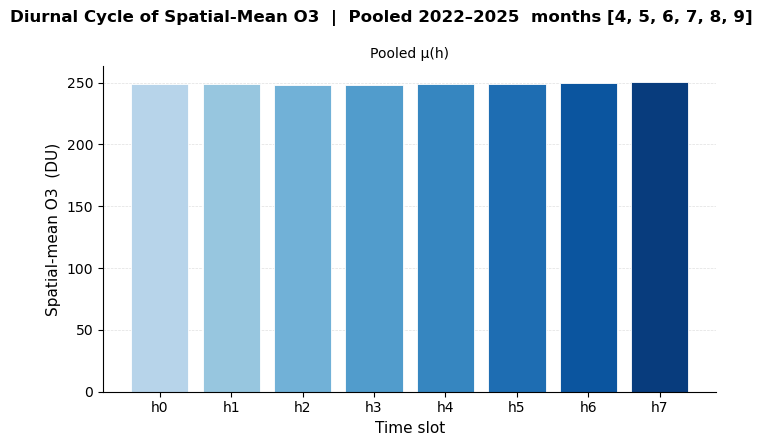

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_mean/hourly_mean_pooled.png


In [4]:
fig, ax = plt.subplots(figsize=(7, 4.5))
fig.suptitle(
    f'Diurnal Cycle of Spatial-Mean O3  |  '
    f'Pooled {YEARS[0]}–{YEARS[-1]}  months {MONTHS}',
    fontsize=12, fontweight='bold'
)

ax.bar(range(N_SLOTS), pooled_mean,
       color=[blues[h] for h in range(N_SLOTS)],
       edgecolor='white', lw=0.6, zorder=2)
ax.set_xticks(range(N_SLOTS))
ax.set_xticklabels(SLOT_LABELS, fontsize=10)
ax.set_xlabel('Time slot', fontsize=11)
ax.set_ylabel('Spatial-mean O3  (DU)', fontsize=11)
ax.set_title('Pooled μ(h)', fontsize=10)
ax.set_ylim(bottom=0)
ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_mean_pooled.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'hourly_mean_pooled.png'}")

## Plot 2 — Monthly heatmaps: μ(h) and σ_b(h)

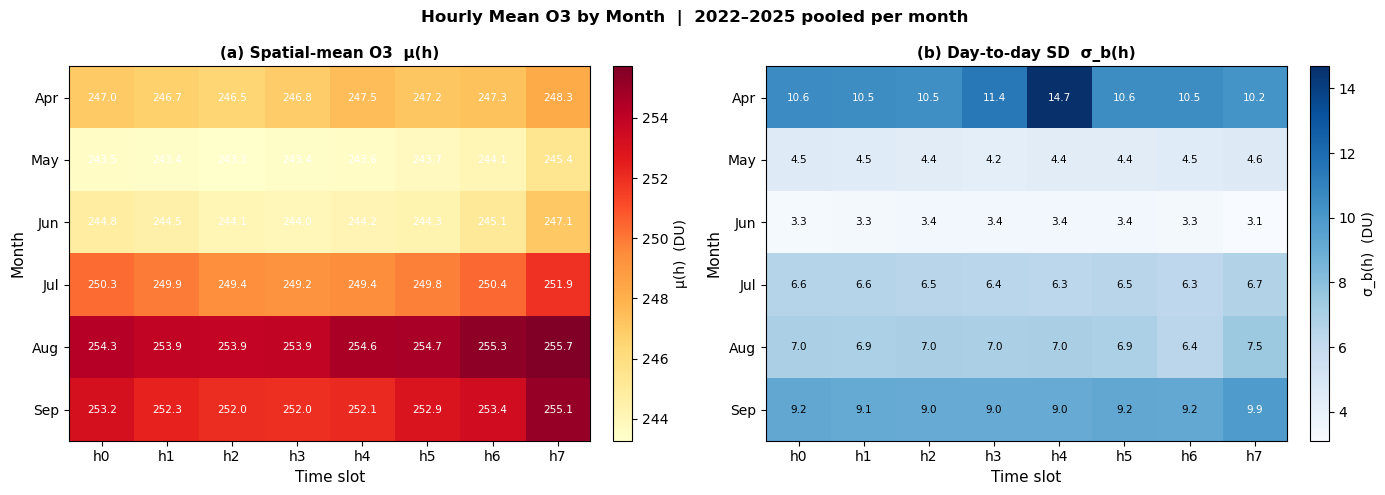

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_mean/hourly_mean_heatmap.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Hourly Mean O3 by Month  |  {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

heatmap_mean = monthly_mean.drop(index='All')
heatmap_std  = monthly_std.drop(index='All')

for ax, mat, cmap, label, title in [
    (axes[0], heatmap_mean, 'YlOrRd', 'μ(h)  (DU)',   '(a) Spatial-mean O3  μ(h)'),
    (axes[1], heatmap_std,  'Blues',  'σ_b(h)  (DU)', '(b) Day-to-day SD  σ_b(h)'),
]:
    vals = mat.values.astype(float)
    im = ax.imshow(vals, cmap=cmap, aspect='auto')
    ax.set_xticks(range(N_SLOTS)); ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_yticks(range(len(mat.index))); ax.set_yticklabels(mat.index, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel('Month', fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label=label)
    vmax = np.nanmax(vals)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if np.isfinite(vals[i, j]):
                ax.text(j, i, f'{vals[i,j]:.1f}', ha='center', va='center',
                        fontsize=7.5,
                        color='white' if vals[i, j] > vmax * 0.65 else 'black')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_mean_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'hourly_mean_heatmap.png'}")

## Plot 3 — Monthly line plots: μ(h) and σ_b(h)

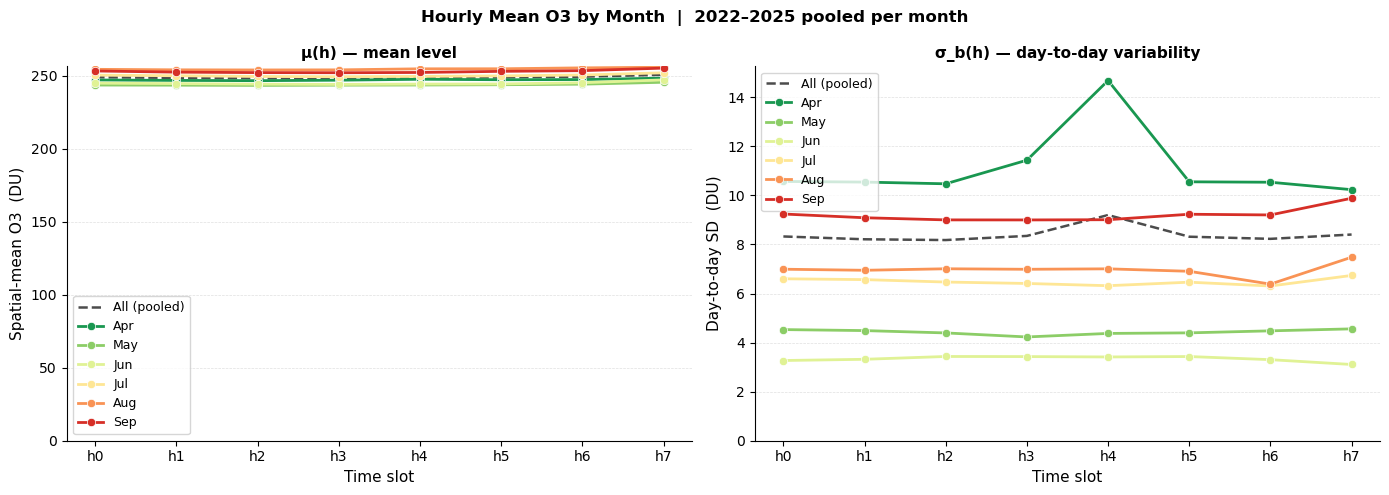

Saved → /Users/joonwonlee/Documents/GEMS_TCO-1/outputs/day/hourly_mean/hourly_mean_monthly_lines.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f'Hourly Mean O3 by Month  |  {YEARS[0]}–{YEARS[-1]} pooled per month',
    fontsize=12, fontweight='bold'
)

for ax, monthly_df, ylabel, title in [
    (axes[0], monthly_mean, 'Spatial-mean O3  (DU)',   'μ(h) — mean level'),
    (axes[1], monthly_std,  'Day-to-day SD  (DU)',     'σ_b(h) — day-to-day variability'),
]:
    # All (pooled): 검정 점선 기준선
    ax.plot(range(N_SLOTS), monthly_df.loc['All'].values.astype(float),
            'k--', lw=1.8, alpha=0.7, label='All (pooled)', zorder=2)

    # Monthly lines
    for i, mo in enumerate(MONTHS):
        mname = MONTH_NAMES[mo]
        ax.plot(range(N_SLOTS), monthly_df.loc[mname].values.astype(float),
                'o-', color=month_colors[i], lw=2.0, ms=6,
                markeredgecolor='white', markeredgewidth=0.5,
                label=mname, zorder=5 + i)

    ax.set_xticks(range(N_SLOTS))
    ax.set_xticklabels(SLOT_LABELS, fontsize=10)
    ax.set_xlabel('Time slot', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(bottom=0)
    ax.yaxis.grid(True, ls='--', lw=0.5, alpha=0.4)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=9, framealpha=0.8, loc='best')

plt.tight_layout()
plt.savefig(OUT_DIR / 'hourly_mean_monthly_lines.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {OUT_DIR / 'hourly_mean_monthly_lines.png'}")